In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

virids_color = cm.viridis(np.linspace(0,1,5))
primary_color = virids_color[0]
secondary_color = virids_color[1]
accent_color = virids_color[2]
danger_color = '#800000'
neutral_color = virids_color[4]
custome_palate = virids_color

In [4]:
df = pd.read_csv('clean_data.csv')
display(df.head(5))

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,...,Product Name,Product Price,shipping date (DateOrders),Shipping Mode,Order_process_time,delay,is_delay,order_month,order_day,order_hour
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,...,Smart watch,327.75,2018-02-03 22:56:00,Standard Class,3,-1,False,1,Wednesday,22
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,...,Smart watch,327.75,2018-01-18 12:27:00,Standard Class,5,1,True,1,Saturday,12
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,...,Smart watch,327.75,2018-01-17 12:06:00,Standard Class,4,0,False,1,Saturday,12
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,...,Smart watch,327.75,2018-01-16 11:45:00,Standard Class,3,-1,False,1,Saturday,11
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,...,Smart watch,327.75,2018-01-15 11:24:00,Standard Class,2,-2,False,1,Saturday,11


# find out company's profit or loss summury

0          91.250000
3          22.860001
4         134.210007
5          95.180000
6          68.430000
             ...    
172759    119.989998
172760     40.000000
172762    141.110001
172763    186.229996
172764    168.949997
Name: Order Profit Per Order, Length: 139354, dtype: float64

profitability_flag
profit        139354
loss           32295
break down      1116
Name: count, dtype: int64

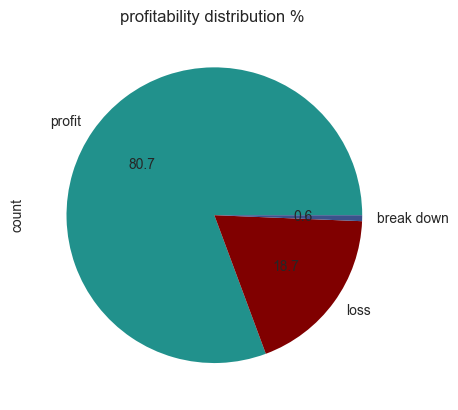

In [5]:
profits_positive = df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order']
display(profits_positive)

# profitability flag base on order profit per order
df['profitability_flag'] = np.where(df['Order Profit Per Order']> 0 , 'profit', np.where(df['Order Profit Per Order'] < 0 ,'loss' , 'break down'))
profit_count = df['profitability_flag'].value_counts()
display(profit_count)
profit_count.plot(kind='pie' , autopct = '%1.1f' , colors = [accent_color , danger_color , secondary_color])
plt.title('profitability distribution % ')
plt.show()

In [6]:
metrics = {}
delivery_late = df[df['delay'] > 0]
metrics['total_order'] = len(df)
metrics['late_delivery'] = len(delivery_late)
metrics['on_time_delivery'] = len(df[df['delay'] == 0])
metrics['total_profit'] = df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum()
metrics['total_loss_due_to_delay'] = df.loc[df['delay'] > 0, 'Order Profit Per Order'].sum()

print("----business KPI------")
for k , v in metrics.items():
    if isinstance(v , float):
        print(f'{k} : {v:.2f}')
    else:
        print(f'{k} : {v:.2f}')



----business KPI------
total_order : 172765.00
late_delivery : 94523.00
on_time_delivery : 36650.00
total_profit : 7514813.81
total_loss_due_to_delay : 2055765.16


# profitability vs delivery time analysis

In [7]:
profit_metrix = df.groupby('delay')['Order Profit Per Order'].agg(
    avg_profit = 'mean',
    total_profit = 'sum',
    order_count = 'count'
)
display(profit_metrix)

,avg_profit,total_profit,order_count
delay,,,
-2,23.360134,4.875961e+05,20873
-1,21.604769,4.476292e+05,20719
0,22.249118,8.154302e+05,36650
1,22.333227,1.194895e+06,53503
2,21.128491,5.821110e+05,27551
3,20.031412,1.356527e+05,6772
4,21.368783,1.431067e+05,6697


In [21]:
delay_distribution = (df['delay'].value_counts(normalize=True) * 100).reset_index()
display(delay_distribution)

,delay,proportion
0,1,30.968657
1,0,21.213788
2,2,15.947096
3,-2,12.081730
4,-1,11.992591
5,3,3.919775
6,4,3.876364


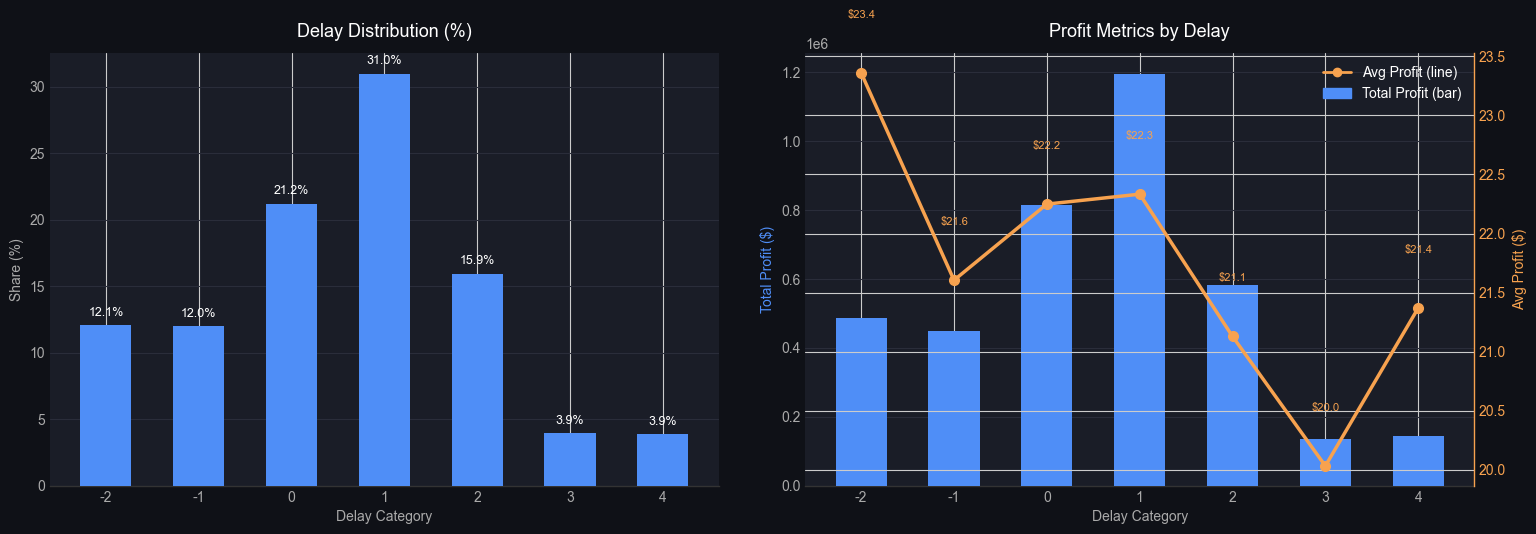

In [ ]:
# Reset index so columns are accessible
profit_metrix = profit_metrix.reset_index()
delay_dist    = delay_distribution.copy()

# Sort both by delay label for consistency
profit_metrix = profit_metrix.sort_values('delay')
delay_dist    = delay_dist.sort_values('delay')

categories = profit_metrix['delay'].astype(str).tolist()
x = np.arange(len(categories))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')

for ax in (ax1, ax2):
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#aaaaaa')
    ax.spines['bottom'].set_color('#333')
    for spine in ['top','right','left']:
        ax.spines[spine].set_visible(False)

bars1 = ax1.bar(
    categories,
    delay_dist.sort_values('delay')['proportion'],   # already in %
    color='#4f8ef7', width=0.55, zorder=3
)
ax1.set_title('Delay Distribution (%)', color='white', fontsize=13, pad=12)
ax1.set_xlabel('Delay Category', color='#aaaaaa')
ax1.set_ylabel('Share (%)',       color='#aaaaaa')
ax1.yaxis.grid(True, color='#2a2d3a', zorder=0)

# Value labels on bars
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 0.5,
             f'{h:.1f}%', ha='center', va='bottom', color='white', fontsize=9)

BAR_COLOR  = '#4f8ef7'
LINE_COLOR = '#f7a24f'
bar_width  = 0.55

# --- Bar: total_profit (primary y-axis) ---
bars2 = ax2.bar(x, profit_metrix['total_profit'],
                color=BAR_COLOR, width=bar_width,
                label='Total Profit', zorder=3)
ax2.set_facecolor('#1a1d27')
ax2.set_title('Profit Metrics by Delay', color='white', fontsize=13, pad=12)
ax2.set_xlabel('Delay Category',  color='#aaaaaa')
ax2.set_ylabel('Total Profit ($)', color=BAR_COLOR)
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.yaxis.grid(True, color='#2a2d3a', zorder=0)

# --- Line: avg_profit (secondary y-axis) ---
ax2b = ax2.twinx()
ax2b.plot(x, profit_metrix['avg_profit'],
          color=LINE_COLOR, marker='o', linewidth=2.5,
          markersize=7, label='Avg Profit', zorder=4)
ax2b.set_ylabel('Avg Profit ($)', color=LINE_COLOR)
ax2b.tick_params(axis='y', colors=LINE_COLOR)
ax2b.spines['right'].set_color(LINE_COLOR)
for spine in ['top','left','bottom']:
    ax2b.spines[spine].set_visible(False)

# Value labels on line points
for xi, val in zip(x, profit_metrix['avg_profit']):
    ax2b.text(xi, val + (profit_metrix['avg_profit'].max() * 0.02),
              f'${val:.1f}', ha='center', color=LINE_COLOR, fontsize=8)
    
# Combine legends from both axes
lines  = [plt.Line2D([0],[0], color=LINE_COLOR, marker='o', lw=2),
          plt.Rectangle((0,0),1,1, color=BAR_COLOR)]
labels = ['Avg Profit (line)', 'Total Profit (bar)']
ax2.legend(lines, labels, loc='upper right',
           facecolor='#1a1d27', edgecolor='#333', labelcolor='white')

plt.tight_layout(pad=3)
plt.show()

* No/early delivery (delay ≤0) yields top avg profit ($21.60–$23.36): 31% of orders (delay=0) drive strong totals; early deliveries rare but efficient.

* Positive delays erode profits progressively: Drops from $22.33 (delay=1) to $20.03 (delay=4), with shrinking volumes/totals (e.g., delay=4: $136k).

* Minimize delays ≥2 (24% of cases): They drag overall profitability despite delay=2 volume spike—focus here for biggest gains.

# bottleneck analysis

In [28]:
df.select_dtypes(include=['object']).columns

Index(['Type', 'Delivery Status', 'Category Name', 'Customer Country',
       'Customer Segment', 'Customer Street', 'Department Name',
       'order date (DateOrders)', 'Order Region', 'Order Status',
       'Product Name', 'shipping date (DateOrders)', 'Shipping Mode',
       'order_day', 'profitability_flag'],
      dtype='object')

In [ ]:
categories = ['Order Region' , 'Customer Segment' , 'Shipping Mode' , 'Order Status' , 'Type' , 'Department Name']

cat_data = {}
for cat in categories:
    cat_df = df.groupby(cat).agg(
        total_delay_order=('delay', 'count'),
        late_order=('is_delay', 'sum')
    ).reset_index()
    cat_df['delay_pct'] = cat_df['late_order'] / cat_df['total_delay_order'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10).reset_index(drop=True)
    cat_data[cat] = cat_df
    display(cat_df)

,Order Region,total_delay_order,late_order,delay_pct
0,Central Africa,1616,948,58.663366
1,Southeast Asia,9136,5113,55.965412
2,Eastern Europe,3785,2118,55.957728
3,South of USA,3855,2156,55.927367
4,East Africa,1781,995,55.867490
5,South Asia,7455,4162,55.828303
6,Western Europe,25867,14432,55.793095
7,West Asia,5746,3194,55.586495
8,US Center,5653,3127,55.315762
9,East of USA,6617,3649,55.145836


,Customer Segment,total_delay_order,late_order,delay_pct
0,Home Office,30817,17060,55.359055
1,Consumer,89420,48855,54.635428
2,Corporate,52528,28608,54.462382


,Shipping Mode,total_delay_order,late_order,delay_pct
0,First Class,26513,26513,100.000000
1,Second Class,33806,26987,79.829024
2,Standard Class,103153,41023,39.769081
3,Same Day,9293,0,0.000000


,Order Status,total_delay_order,late_order,delay_pct
0,PENDING,20227,11177,55.257824
1,PAYMENT_REVIEW,1893,1046,55.256207
2,PENDING_PAYMENT,39832,21912,55.011046
3,COMPLETE,59491,32695,54.957893
4,PROCESSING,21902,11953,54.574925
5,CLOSED,19616,10545,53.757137
6,ON_HOLD,9804,5195,52.988576


,Type,total_delay_order,late_order,delay_pct
0,PAYMENT,41725,22958,55.022169
1,TRANSFER,42129,23130,54.902799
2,DEBIT,69295,37890,54.679270
3,CASH,19616,10545,53.757137


,Department Name,total_delay_order,late_order,delay_pct
0,Health and Beauty,346,197,56.936416
1,Pet Shop,472,267,56.567797
2,Technology,1396,777,55.659026
3,Outdoors,9267,5155,55.627495
4,Fitness,2374,1316,55.433867
5,Golf,31768,17381,54.712289
6,Footwear,13891,7595,54.675689
7,Apparel,46884,25630,54.666837
8,Fan Shop,64033,34958,54.593725
9,Discs Shop,1943,1050,54.040144


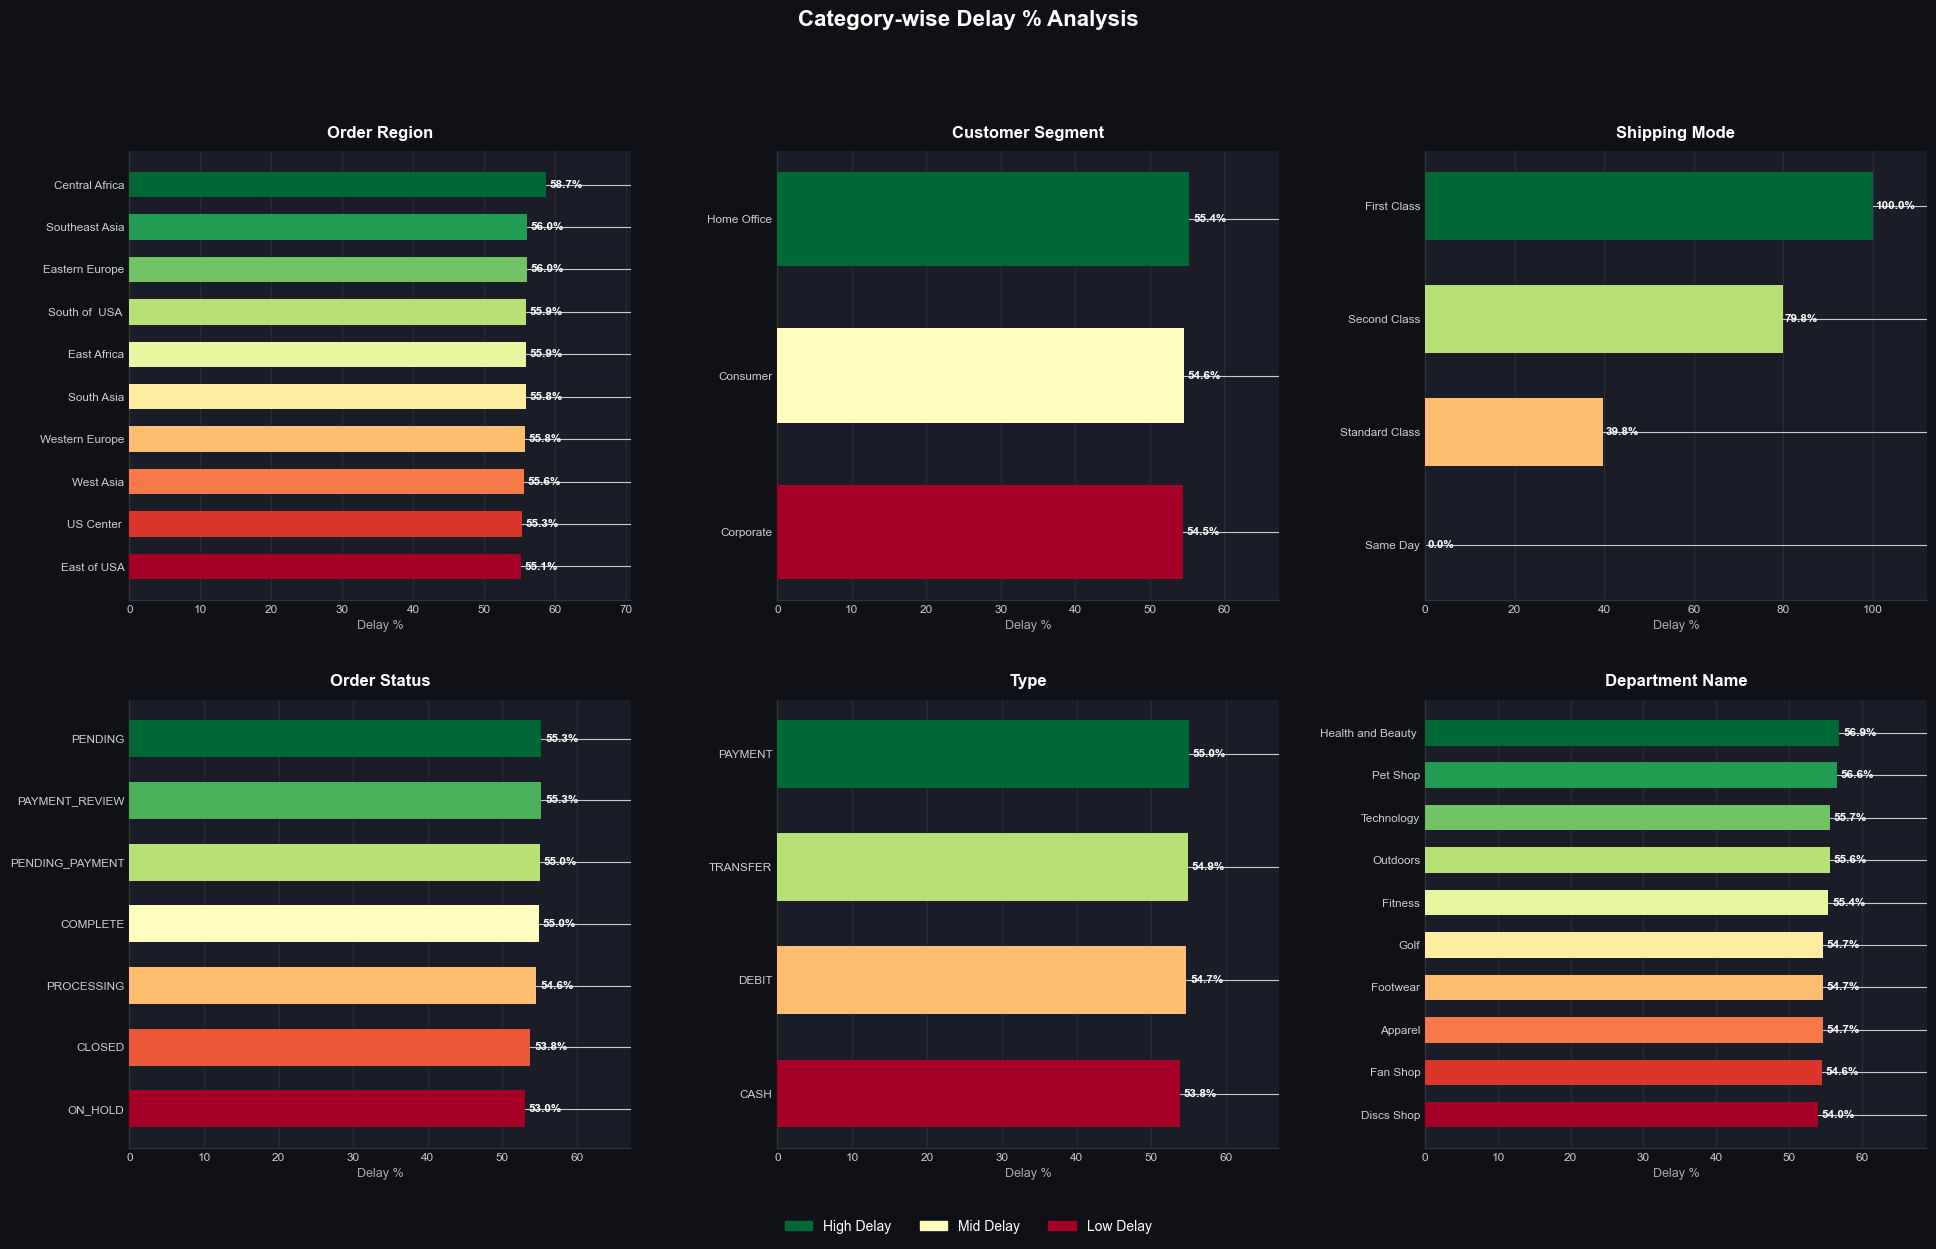

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.patch.set_facecolor('#0f1117')
axes = axes.flatten()

def get_colors(n):
    cmap = plt.cm.RdYlGn_r
    return [cmap(i / max(n - 1, 1)) for i in range(n)]

for idx, cat in enumerate(categories):
    ax = axes[idx]

    df_ = cat_data[cat].copy()
    df_ = df_.sort_values('delay_pct', ascending=False).reset_index(drop=True)

    labels = df_[cat].astype(str).tolist()
    values = df_['delay_pct'].tolist()
    colors = get_colors(len(labels))

    bars = ax.barh(labels, values, color=colors, height=0.6, edgecolor='none', zorder=3)

    for bar, val in zip(bars, values):
        ax.text(
            val + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%',
            va='center',
            ha='left',
            color='white',
            fontsize=8.5,
            fontweight='bold'
        )

    ax.invert_yaxis()  # highest delay_pct at top

    ax.set_facecolor('#1a1d27')
    ax.set_title(cat, color='white', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Delay %', color='#aaaaaa', fontsize=9)
    ax.set_xlim(0, max(values) + 12)
    ax.tick_params(colors='#cccccc', labelsize=8.5)
    ax.xaxis.grid(True, color='#2a2d3a', linewidth=0.7, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333')
    ax.spines['bottom'].set_color('#333')

low  = mpatches.Patch(color=plt.cm.RdYlGn_r(0.0), label='High Delay')
mid  = mpatches.Patch(color=plt.cm.RdYlGn_r(0.5), label='Mid Delay')
high = mpatches.Patch(color=plt.cm.RdYlGn_r(1.0), label='Low Delay')

fig.legend(
    handles=[low, mid, high],
    loc='lower center',
    ncol=3,
    facecolor='#1a1d27',
    edgecolor='#333',
    labelcolor='white',
    fontsize=10,
    bbox_to_anchor=(0.5, -0.02)
)

fig.suptitle(
    'Category-wise Delay % Analysis',
    color='white',
    fontsize=16,
    fontweight='bold',
    y=1.01
)

plt.tight_layout(pad=3)
plt.show()

# Time Based Analysis

In [79]:
# order_time_zone = ['order_month' , 'order_hour' , 'order_day']

# cat_data = {}
# for cat in order_time_zone:
#     cat_df = df.groupby(cat)['is_delay'].mean().reset_index()
#     cat_df['delay_pct'] = cat_df['is_delay'] * 100
#     cat_df = cat_df.sort_values(cat, ascending=True).reset_index(drop=True)
#     cat_data[cat] = cat_df
#     display(cat_df)

from pandas.api.types import CategoricalDtype

order_time_zone = ['order_month', 'order_hour', 'order_day']
weekday_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
weekday_type = CategoricalDtype(categories=weekday_order, ordered=True)

cat_data = {}

for cat in order_time_zone:
    cat_df = df.groupby(cat)['is_delay'].mean().reset_index()
    cat_df['delay_pct'] = cat_df['is_delay'] * 100

    if cat == 'order_day':
        cat_df[cat] = cat_df[cat].astype(weekday_type)
        cat_df = cat_df.sort_values(cat, ascending=True)
    else:
        cat_df = cat_df.sort_values(cat, ascending=True)

    cat_df = cat_df.reset_index(drop=True)
    cat_data[cat] = cat_df
    display(cat_df)

,order_month,is_delay,delay_pct
0,1,0.542542,54.254150
1,2,0.546046,54.604550
2,3,0.548094,54.809390
3,4,0.545042,54.504230
4,5,0.549980,54.998022
5,6,0.547645,54.764535
6,7,0.537310,53.731048
7,8,0.553871,55.387128
8,9,0.553885,55.388454
9,10,0.540970,54.097044


,order_hour,is_delay,delay_pct
0,0,0.540686,54.068641
1,1,0.554227,55.422680
2,2,0.551937,55.193735
3,3,0.541420,54.142012
4,4,0.536747,53.674683
5,5,0.552672,55.267154
6,6,0.528388,52.838802
7,7,0.549882,54.988239
8,8,0.531329,53.132903
9,9,0.543575,54.357480


,order_day,is_delay,delay_pct
0,Sunday,0.551524,55.152418
1,Monday,0.555338,55.533838
2,Tuesday,0.539841,53.984137
3,Wednesday,0.548452,54.845175
4,Thursday,0.547202,54.720188
5,Friday,0.544884,54.488442
6,Saturday,0.542619,54.261937


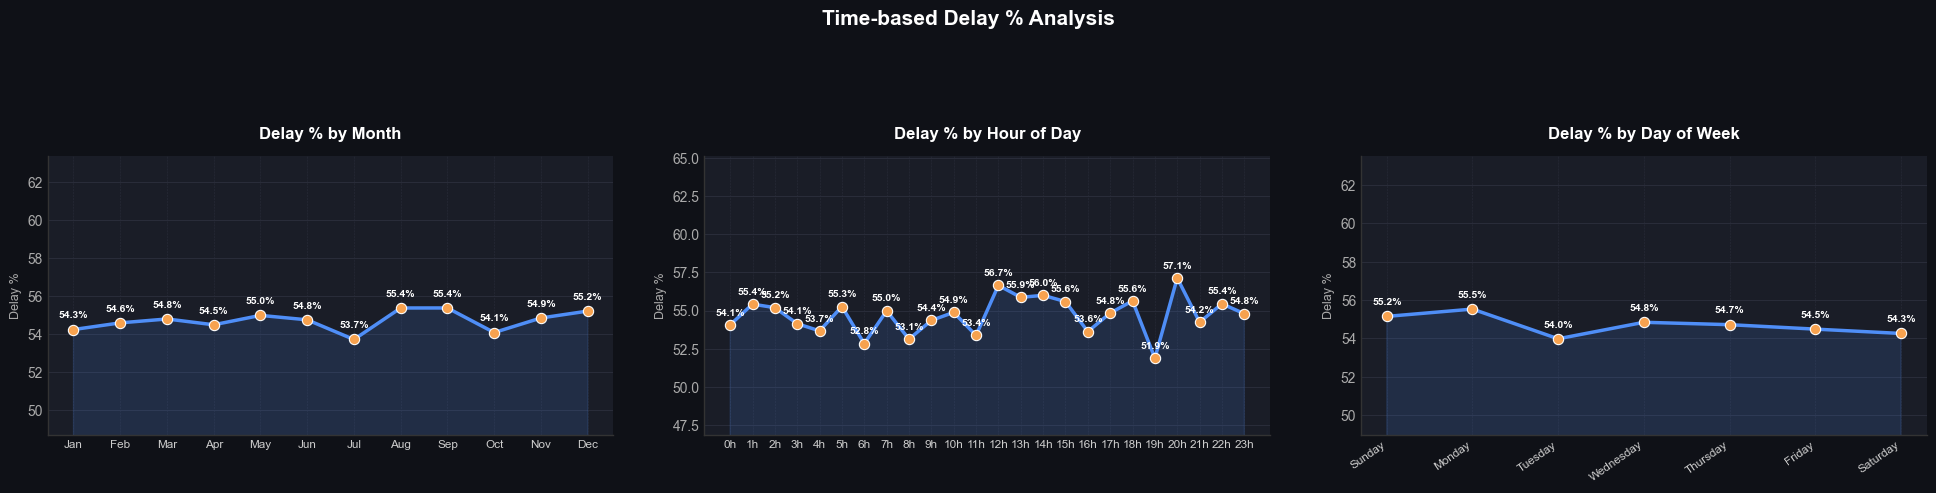

In [ ]:
month_labels = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
                7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

titles = {
    'order_month' : 'Delay % by Month',
    'order_hour'  : 'Delay % by Hour of Day',
    'order_day'   : 'Delay % by Day of Week'
}
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.patch.set_facecolor('#0f1117')

ACCENT   = '#4f8ef7'
DOT_COL  = '#f7a24f'
BG       = '#1a1d27'
GRID_COL = '#2a2d3a'

for idx, cat in enumerate(order_time_zone):
    ax  = axes[idx]
    df_ = cat_data[cat]

    x_vals = df_[cat].astype(str) if cat == 'order_day' else df_[cat]
    y_vals = df_['delay_pct']
    x_pos  = range(len(x_vals))

    # --- Shaded area under line ---
    ax.fill_between(x_pos, y_vals, alpha=0.15, color=ACCENT, zorder=2)

    # --- Main line ---
    ax.plot(x_pos, y_vals, color=ACCENT, linewidth=2.5,
            zorder=3, solid_capstyle='round')

    # --- Dots on each point ---
    ax.scatter(x_pos, y_vals, color=DOT_COL, s=55,
               zorder=4, edgecolors='white', linewidths=0.8)

    # --- delay_pct label on every point ---
    for xi, yi in zip(x_pos, y_vals):
        ax.text(xi, yi + 0.5, f'{yi:.1f}%',
                ha='center', va='bottom',
                color='white', fontsize=7.5, fontweight='bold')

    # --- X-axis tick labels ---
    if cat == 'order_month':
        tick_labels = [month_labels.get(int(v), v) for v in df_[cat]]
    elif cat == 'order_day':
        tick_labels = df_[cat].astype(str).tolist()
    else:                          # order_hour → "9h", "10h" …
        tick_labels = [f'{int(v)}h' for v in df_[cat]]

    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(tick_labels, rotation=35 if cat=='order_day' else 0,
                       ha='right' if cat=='order_day' else 'center',
                       color='#cccccc', fontsize=8.5)

    # --- Styling ---
    ax.set_facecolor(BG)
    ax.set_title(titles[cat], color='white', fontsize=12,
                 fontweight='bold', pad=12)
    ax.set_ylabel('Delay %', color='#aaaaaa', fontsize=9)
    ax.set_ylim(y_vals.min() - 5, y_vals.max() + 8)  # breathing room
    ax.tick_params(axis='y', colors='#aaaaaa')
    ax.yaxis.grid(True, color=GRID_COL, linewidth=0.7, zorder=0)
    ax.xaxis.grid(True, color=GRID_COL, linewidth=0.4,
                  linestyle='--', zorder=0)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('#333')

fig.suptitle('Time-based Delay % Analysis',
             color='white', fontsize=15, fontweight='bold', y=1.03)

plt.tight_layout(pad=3)
plt.show()

# product level profit leakage analysis

Which product categories are generating high revenue but low (or negative) profit, and why?

In [88]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Name', 'Customer Country',
       'Customer Segment', 'Customer Street', 'Department Id',
       'Department Name', 'order date (DateOrders)',
       'Order Item Product Price', 'Order Item Profit Ratio', 'Sales',
       'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order_process_time', 'delay', 'is_delay',
       'order_month', 'order_day', 'order_hour', 'profitability_flag'],
      dtype='object')

In [103]:
category_profit =  df.groupby('Category Name').agg(
    profit = ('Order Profit Per Order' , 'sum'),
    revenue = ('Sales' , 'sum'),
    Avg_Profit_Ratio=('Order Item Profit Ratio', 'mean'),
).sort_values('revenue' , ascending=False)

category_profit['Profit_Margin_%'] = (
    category_profit['profit'] / category_profit['revenue'] * 100
).round(2)

# high revenue but low margin
margin_median = category_profit['Profit_Margin_%'].median()
revnue_median = category_profit['revenue'].median()

final_output = category_profit[
    (category_profit['revenue'] > revnue_median) & 
    (category_profit['Profit_Margin_%'] < margin_median)
].sort_values('revenue' , ascending=False)

print("---overall profit and revenue-----")
display(category_profit.head(10))
print('---high revenue low margin----')
display(final_output)

---overall profit and revenue-----


,profit,revenue,Avg_Profit_Ratio,Profit_Margin_%
Category Name,,,,
Fishing,731576.187155,6.637668e+06,0.122856,11.02
Cleats,474629.509779,4.244594e+06,0.125111,11.18
Camping & Hiking,409895.618131,3.946837e+06,0.115917,10.39
Cardio Equipment,362984.698572,3.533289e+06,0.118216,10.27
Women's Apparel,334335.529529,3.011600e+06,0.122142,11.10
Water Sports,308981.340066,2.981851e+06,0.115641,10.36
Indoor/Outdoor Games,302403.770481,2.765543e+06,0.123107,10.93
Men's Footwear,296711.090173,2.763977e+06,0.119595,10.73
Shop By Sport,125077.030333,1.253396e+06,0.113120,9.98


---high revenue low margin----


,profit,revenue,Avg_Profit_Ratio,Profit_Margin_%
Category Name,,,,
Fishing,731576.187155,6.637668e+06,0.122856,11.02
Camping & Hiking,409895.618131,3.946837e+06,0.115917,10.39
Cardio Equipment,362984.698572,3.533289e+06,0.118216,10.27
Water Sports,308981.340066,2.981851e+06,0.115641,10.36
Indoor/Outdoor Games,302403.770481,2.765543e+06,0.123107,10.93
Men's Footwear,296711.090173,2.763977e+06,0.119595,10.73
Shop By Sport,125077.030333,1.253396e+06,0.113120,9.98
Computers,69232.110159,6.375000e+05,0.121506,10.86
Electronics,38510.059927,3.568364e+05,0.122397,10.79


In [107]:
print("Columns in final_output:")
print(final_output.columns.tolist())

Columns in final_output:
['profit', 'revenue', 'Avg_Profit_Ratio', 'Profit_Margin_%']


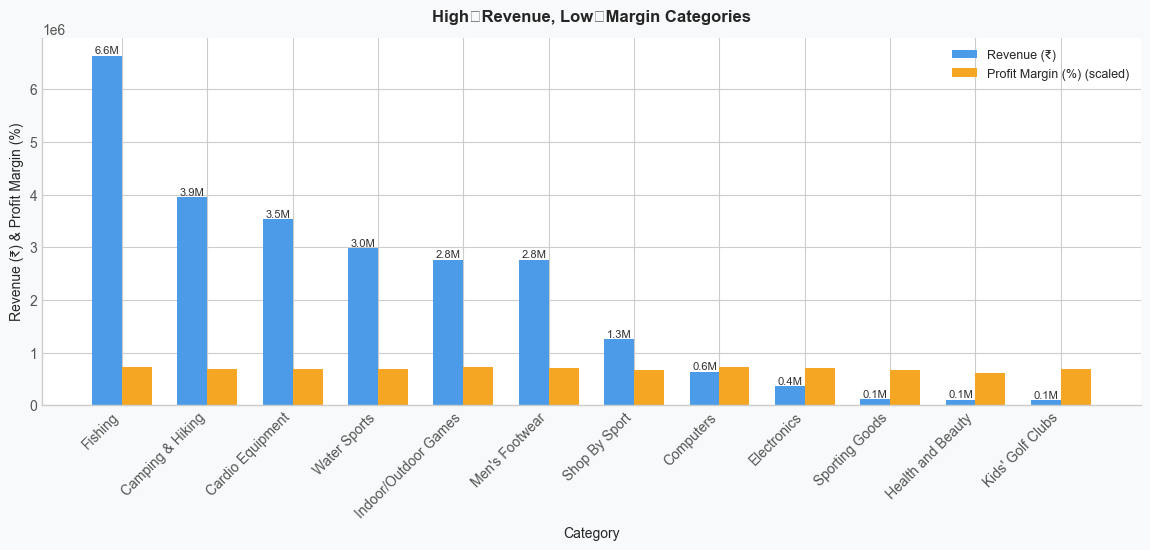

In [ ]:
plot_data = final_output.copy()
categories = plot_data.index.tolist()
revenue  = plot_data['revenue'].values
profit   = plot_data['profit'].values
margin   = plot_data['Profit_Margin_%'].values

# Normalize margin to roughly same scale as revenue (for visual comparison)
margin_scaled = margin * (revenue.max() / 100)  # scale to ~1% = 1 pixel of revenue scale

# Plot side‑by‑side bars
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#FFFFFF")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#CCCCCC")
ax.tick_params(colors="#555555")

bars1 = ax.bar(x - width/2, revenue, width, label='Revenue (₹)', color='#4C9BE8')
bars2 = ax.bar(x + width/2, margin_scaled, width, label='Profit Margin (%) (scaled)', color='#F5A623')

ax.set_title("High‑Revenue, Low‑Margin Categories", fontweight="bold", pad=12)
ax.set_xlabel("Category")
ax.set_ylabel("Revenue (₹) & Profit Margin (%)")
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha='right')

# Optionally annotate revenue on bars
for bar, val in zip(bars1, revenue):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height(),
        f"{val/1e6:.1f}M", ha="center", va="bottom", fontsize=8, color="#333"
    )

ax.legend(framealpha=0.7, fontsize=9)
plt.tight_layout(pad=2.5)
plt.show()

* Categories like Fishing, Camping & Hiking, Cardio Equipment, and Water Sports are among the top revenue generators (all above ₹2.7M–₹6.6M) but operate with narrow margins of around 10–11%

Profit Margin % is tightly packed between ~9.15% and 11.02% for all entries, which suggests:

* most of these categories are priced in a similar band (e.g., commodity‑like or highly competitive categories),

* there is little “star” category that stands out as meaningfully more profitable on margin.